---
title: Sentinel 1 Surface Soil Moisture (SSM)
subtitle: Learn how to compute surface soil moisture from Sentinel-1 data
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-01-07
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing", "Sentinel-1", "soil moisture", "radar", "SAR"]
tags: ["Sentinel-1", "Soil Moisture", "SSM", "Radar", "SAR", "Earth Observation", "Remote Sensing"]
releaseDate: 2026-01-07
datePublished: 2026-01-07
dateModified: 2026-01-07
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

- [Introduction](#Introduction_SSM)
- [Setup](#Setup_SSM)
- [Configuration](#Configuration_SSM)
- [Helper functions](#Helper-functions_SSM)
- [Creating a reference period datacute](#Creating-reference-period-datacube_SSM)
- [Preprocess reference period data](#Preprocess-reference-period-data_SSM)
- [Geocode reference period data](#Geocode-reference-period-data_SSM)
- [Calculate dry and wet references](#Calculate-dry-and-wet-references_SSM)
- [Search current period data](#Search-current-period-data_SSM)
- [Process current observations](#Process-current-observations_SSM)
- [Calculate surface soil moisture](#Calculate-surface-soil-moisture_SSM)
- [Filter urban and water areas](#Filter-urban-and-water-areas_SSM)
- [Visualize results](#Visualize-results_SSM)

(Introduction_SSM)=
## Introduction

In this notebook, we will demonstrate how to compute surface soil moisture (SSM) from Sentinel-1 data using EOPF Zarr data. Surface soil moisture is a crucial parameter for various applications, including agriculture, hydrology, and climate studies.

The original notebook comes from the [Copernicus Data Space Ecosystem](https://documentation.dataspace.copernicus.eu/APIs/openEO/openeo-community-examples/python/SurfaceSoilMoisture/SoilMoisture.html)

:::{hint} Overview
**Questions**
- How can we estimate Surface Soil Moisture from Sentinel-1 data?
- How can we compute the difference between the reference and current data?

**Objectives**
- Learn how to create and preprocess Sentinel-1 data
- Perform geocoding, spatial slicing, interpolation
- Compute Surface Soil Moisture
:::

(Setup_SSM)=
## Setup
Start importing the necessary libraries

In [ ]:
import pystac_client
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from dask_gateway import Gateway

xr.set_options(display_expand_attrs=False)

In [ ]:
"""
gate = Gateway("https://dask.user.eopf.eodc.eu",
               proxy_address="tls://dask.user.eopf.eodc.eu:10000",
               auth="jupyterhub")
"""

# Dask Gateway automatically loads the correct configuration.
# So the code below is identical to the comment above
gate = Gateway()
cluster = gate.new_cluster()
cluster

In [ ]:
cluster.scale(4)

cluster.adapt(minimum=1, maximum=4)

In [ ]:
client = cluster.get_client()

client

(Configuration_SSM)=
## Configuration

In [2]:
# Bounding box [min_lon, min_lat, max_lon, max_lat]
bbox = [139.300, -35.516, 139.450, -35.350]

# Reference period (for establishing dry and wet conditions)
reference_start = "2019-12-01"
reference_end = "2020-02-02"

# Current period (observation to calculate SSM for)
current_start = "2020-01-02"
current_end = "2020-01-28"

# Spatial resolution for geocoded output (degrees)
spatial_resolution = 0.0001

# STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

(Helper-functions_SSM)=
## Helper functions

In [3]:
def build_slice(shape, idx, offset=2):
    i0 = int(min(idx[0]))
    i1 = int(max(idx[1]))

    def clamp_slice(i, dim_size):
        start = max(0, i - offset)
        end = min(dim_size - 1, i + offset)
        return slice(start, end + 1)

    return [clamp_slice(i0, shape[0]), clamp_slice(i1, shape[1])]

In [4]:
def create_regular_grid(min_x, max_x, min_y, max_y, spatialres):
    width = int(np.ceil((max_x - min_x) / spatialres))
    height = int(np.ceil((max_y - min_y) / spatialres))

    half_pixel = spatialres / 2.0
    x_regular = np.linspace(
        min_x + half_pixel, max_x - half_pixel, width, dtype=np.float32
    )
    y_regular = np.linspace(
        min_y + half_pixel, max_y - half_pixel, height, dtype=np.float32
    )

    grid_x_regular, grid_y_regular = np.meshgrid(x_regular, y_regular)

    return grid_x_regular, grid_y_regular

In [5]:
def geocode_grd(sigma_0, grid_x_regular, grid_y_regular):
    grid_lat = sigma_0.latitude.values
    grid_lon = sigma_0.longitude.values

    # Set border values to zero to avoid artifacts
    sigma_0["vh"].data[[0, -1], :] = 0
    sigma_0["vh"].data[:, [0, -1]] = 0
    sigma_0["vv"].data[[0, -1], :] = 0
    sigma_0["vv"].data[:, [0, -1]] = 0

    interpolated_values_grid_vh = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vh.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    interpolated_values_grid_vv = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vv.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    ds = xr.Dataset(
        coords=dict(
            time=(["time"], [sigma_0.time.values]),
            y=(["y"], grid_y_regular[:, 0]),
            x=(["x"], grid_x_regular[0, :]),
        )
    )
    ds["vh"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vh, 0))
    ds["vv"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vv, 0))
    ds = ds.where(ds != 0)

    return ds

In [6]:
def preprocess_grd(grd_path, bbox):
    # Data Access
    dt = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"][:-2], "ns")

    group_VH = [x for x in dt.children if "VH" in x][0]
    grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
    group_VV = [x for x in dt.children if "VV" in x][0]
    grd["vv"] = dt[group_VV].measurements.to_dataset().grd

    # Spatial Slicing
    gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
    mask = (
        (gcps.latitude < bbox[3])
        & (gcps.latitude > bbox[1])
        & (gcps.longitude < bbox[2])
        & (gcps.longitude > bbox[0])
    )
    idx = np.where(mask == 1)
    if len(idx[0]) == 0 or len(idx[1]) == 0:
        return None
    azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

    gcps_crop = gcps.isel(
        dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
    )

    azimuth_time_min = gcps_crop.azimuth_time.min().values
    azimuth_time_max = gcps_crop.azimuth_time.max().values

    ground_range_min = gcps_crop.ground_range.min().values
    ground_range_max = gcps_crop.ground_range.max().values

    grd_crop = grd.sel(
        dict(
            azimuth_time=slice(azimuth_time_min, azimuth_time_max),
            ground_range=slice(ground_range_min, ground_range_max),
        )
    )

    gcps_crop_interp = gcps_crop.interp_like(grd_crop)
    grd_crop = grd_crop.assign_coords(
        {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
    )
    mask_2 = (
        (gcps_crop_interp.latitude < bbox[3])
        & (gcps_crop_interp.latitude > bbox[1])
        & (gcps_crop_interp.longitude < bbox[2])
        & (gcps_crop_interp.longitude > bbox[0])
    )
    grd_crop = grd_crop.where(mask_2.compute(), drop=True)

    # Calibration
    sigma_lut = dt[group_VH].quality.calibration.sigma_nought

    sigma_lut_line_pixel = xr.DataArray(
        data=sigma_lut.data,
        dims=["line", "pixel"],
        coords=dict(
            line=(["line"], sigma_lut.line.values),
            pixel=(["pixel"], sigma_lut.pixel.values),
        ),
    )
    grd_line_pixel = xr.DataArray(
        data=grd_crop.vh.data,
        dims=["line", "pixel"],
        coords=dict(
            line=(["line"], grd_crop.vh.line.values),
            pixel=(["pixel"], grd_crop.vh.pixel.values),
        ),
    )
    sigma_lut_interp_line_pixel = sigma_lut_line_pixel.interp_like(
        grd_line_pixel, method="linear"
    )

    sigma_lut_interp = xr.DataArray(
        data=sigma_lut_interp_line_pixel.data,
        dims=["azimuth_time", "ground_range"],
        coords=dict(
            azimuth_time=(["azimuth_time"], grd_crop.azimuth_time.values),
            ground_range=(["ground_range"], grd_crop.ground_range.values),
        ),
    )

    sigma_0 = (abs(grd_crop.astype(np.float32)) ** 2) / (sigma_lut_interp**2)
    sigma_0 = sigma_0.assign_coords(time=t)

    return [
        sigma_0,
        (
            np.min(sigma_0.latitude.values).item(),
            np.max(sigma_0.latitude.values).item(),
        ),
        (
            np.min(sigma_0.longitude.values).item(),
            np.max(sigma_0.longitude.values).item(),
        ),
    ]

(Creating-reference-period-datacube_SSM)=
## Creating a reference period datacube

In [7]:
ref_items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=[reference_start, reference_end],
    ).items()
)
print(f"Found {len(ref_items)} reference images")

grd_paths_ref = [p.assets["product"].href for p in ref_items]

Found 6 reference images


(Preprocess-reference-period-data_SSM)=
## Preprocess reference period data

In [8]:
%%time

grd_products = []
for grd_path in grd_paths_ref:
    result = preprocess_grd(grd_path, bbox)
    if result is not None:
        grd_products.append(result)

print(f"Successfully preprocessed {len(grd_products)} images")

Successfully preprocessed 6 images
CPU times: user 13 s, sys: 8.24 s, total: 21.3 s
Wall time: 33.4 s


(Geocode-reference-period-data_SSM)=
## Geocode reference period data

In [9]:
min_lat = np.min([i[1][0] for i in grd_products])
max_lat = np.max([i[1][1] for i in grd_products])
min_lon = np.min([i[2][0] for i in grd_products])
max_lon = np.max([i[2][1] for i in grd_products])

grid_x_regular, grid_y_regular = create_regular_grid(
    min_lon, max_lon, min_lat, max_lat, spatial_resolution
)

print(f"Grid shape: {grid_y_regular.shape}")

Grid shape: (2328, 2576)


In [10]:
%%time

grd_products_geocoded = []
for grd_product in grd_products:
    result = geocode_grd(grd_product[0], grid_x_regular, grid_y_regular)
    grd_products_geocoded.append(result)

sigma_0_ref_series = xr.concat(grd_products_geocoded, dim="time").sortby("time")

# Group by date and take max
sigma_0_ref_series = (
    sigma_0_ref_series.groupby("time.date")
    .max("time")
    .rename(dict(date="time"))
)

# Drop NaN-only time slices
sigma_0_ref_series = sigma_0_ref_series.where(
    ~np.isnan(sigma_0_ref_series), drop=True
)

sigma_0_ref_series

CPU times: user 4min 18s, sys: 4.4 s, total: 4min 22s
Wall time: 4min 29s


<xarray.Dataset> Size: 240MB
Dimensions:  (time: 6, y: 1662, x: 1502)
Coordinates:
  * y        (y) float32 7kB -35.52 -35.52 -35.52 ... -35.35 -35.35 -35.35
  * x        (x) float32 6kB 139.3 139.3 139.3 139.3 ... 139.4 139.4 139.4 139.5
  * time     (time) object 48B 2019-12-01 2019-12-13 ... 2020-01-18 2020-01-30
Data variables:
    vh       (time, y, x) float64 120MB nan nan nan nan nan ... nan nan nan nan
    vv       (time, y, x) float64 120MB nan nan nan nan nan ... nan nan nan nan

(Calculate-dry-and-wet-references_SSM)=
## Calculate dry and wet references

In [11]:
# Dry reference = minimum backscatter (driest conditions)
dry_ref = sigma_0_ref_series.min(dim="time")

# Wet reference = maximum backscatter (wettest conditions)
wet_ref = sigma_0_ref_series.max(dim="time")

(Search-current-period-data_SSM)=
## Search current period data

In [12]:
cur_items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=[current_start, current_end],
    ).items()
)
print(f"Found {len(cur_items)} current period images")
print(f"Using most recent: {cur_items[-1].datetime}")

grd_path_current = [p.assets["product"].href for p in cur_items][-1]

Found 2 current period images
Using most recent: 2020-01-06 19:57:35.085442+00:00


(Process-current-observations_SSM)=
## Process current observations

In [13]:
%%time

grd_product_current = preprocess_grd(grd_path_current, bbox)

sigma_0_current = geocode_grd(
    grd_product_current[0], grid_x_regular, grid_y_regular
)

sigma_0_current = sigma_0_current.isel(time=0)
sigma_0_current

CPU times: user 42.9 s, sys: 3.27 s, total: 46.2 s
Wall time: 50.6 s


<xarray.Dataset> Size: 96MB
Dimensions:  (y: 2328, x: 2576)
Coordinates:
    time     datetime64[ns] 8B 2020-01-06T19:57:35.085440
  * y        (y) float32 9kB -35.55 -35.55 -35.55 ... -35.32 -35.32 -35.32
  * x        (x) float32 10kB 139.2 139.2 139.2 139.2 ... 139.5 139.5 139.5
Data variables:
    vh       (y, x) float64 48MB nan nan nan nan nan nan ... nan nan nan nan nan
    vv       (y, x) float64 48MB nan nan nan nan nan nan ... nan nan nan nan nan

(Calculate-surface-soil-moisture_SSM)=
## Calculate surface soil moisture

In [14]:
# SSM = (current - dry) / (wet - dry)
SSM_vv = (sigma_0_current.vv - dry_ref.vv) / (wet_ref.vv - dry_ref.vv)
SSM_vh = (sigma_0_current.vh - dry_ref.vh) / (wet_ref.vh - dry_ref.vh)

# Clip to [0, 1] range
SSM_vv = SSM_vv.clip(0, 1)
SSM_vh = SSM_vh.clip(0, 1)

print(f"SSM (VV) - Mean: {float(SSM_vv.mean()):.3f}, Std: {float(SSM_vv.std()):.3f}")
print(f"SSM (VH) - Mean: {float(SSM_vh.mean()):.3f}, Std: {float(SSM_vh.std()):.3f}")

SSM (VV) - Mean: 0.277, Std: 0.302
SSM (VH) - Mean: 0.318, Std: 0.324


(Filter-urban-and-water-areas_SSM)=
## Filter urban and water areas

In [15]:
# Calculate average reference backscatter
average_ref = sigma_0_ref_series.mean(dim="time")

# Convert to dB scale: 10 * log10(sigma0)
average_ref_db = 10 * np.log10(average_ref)

In [16]:
# Create mask to filter urban areas (>-6dB) and water bodies (<-17dB)
VV_db = average_ref_db.vv
mask = (VV_db > -6) | (VV_db < -17)

# Apply mask to SSM (mask out urban and water areas)
SSM_vv_filtered = SSM_vv.where(~mask)
SSM_vh_filtered = SSM_vh.where(~mask)

pixels_masked = int(mask.sum().values)
total_pixels = int(mask.size)
print(f"\nMasked pixels: {pixels_masked} ({100*pixels_masked/total_pixels:.1f}%)")


Masked pixels: 1172926 (47.0%)


(Visualize-results_SSM)=
## Visualize results

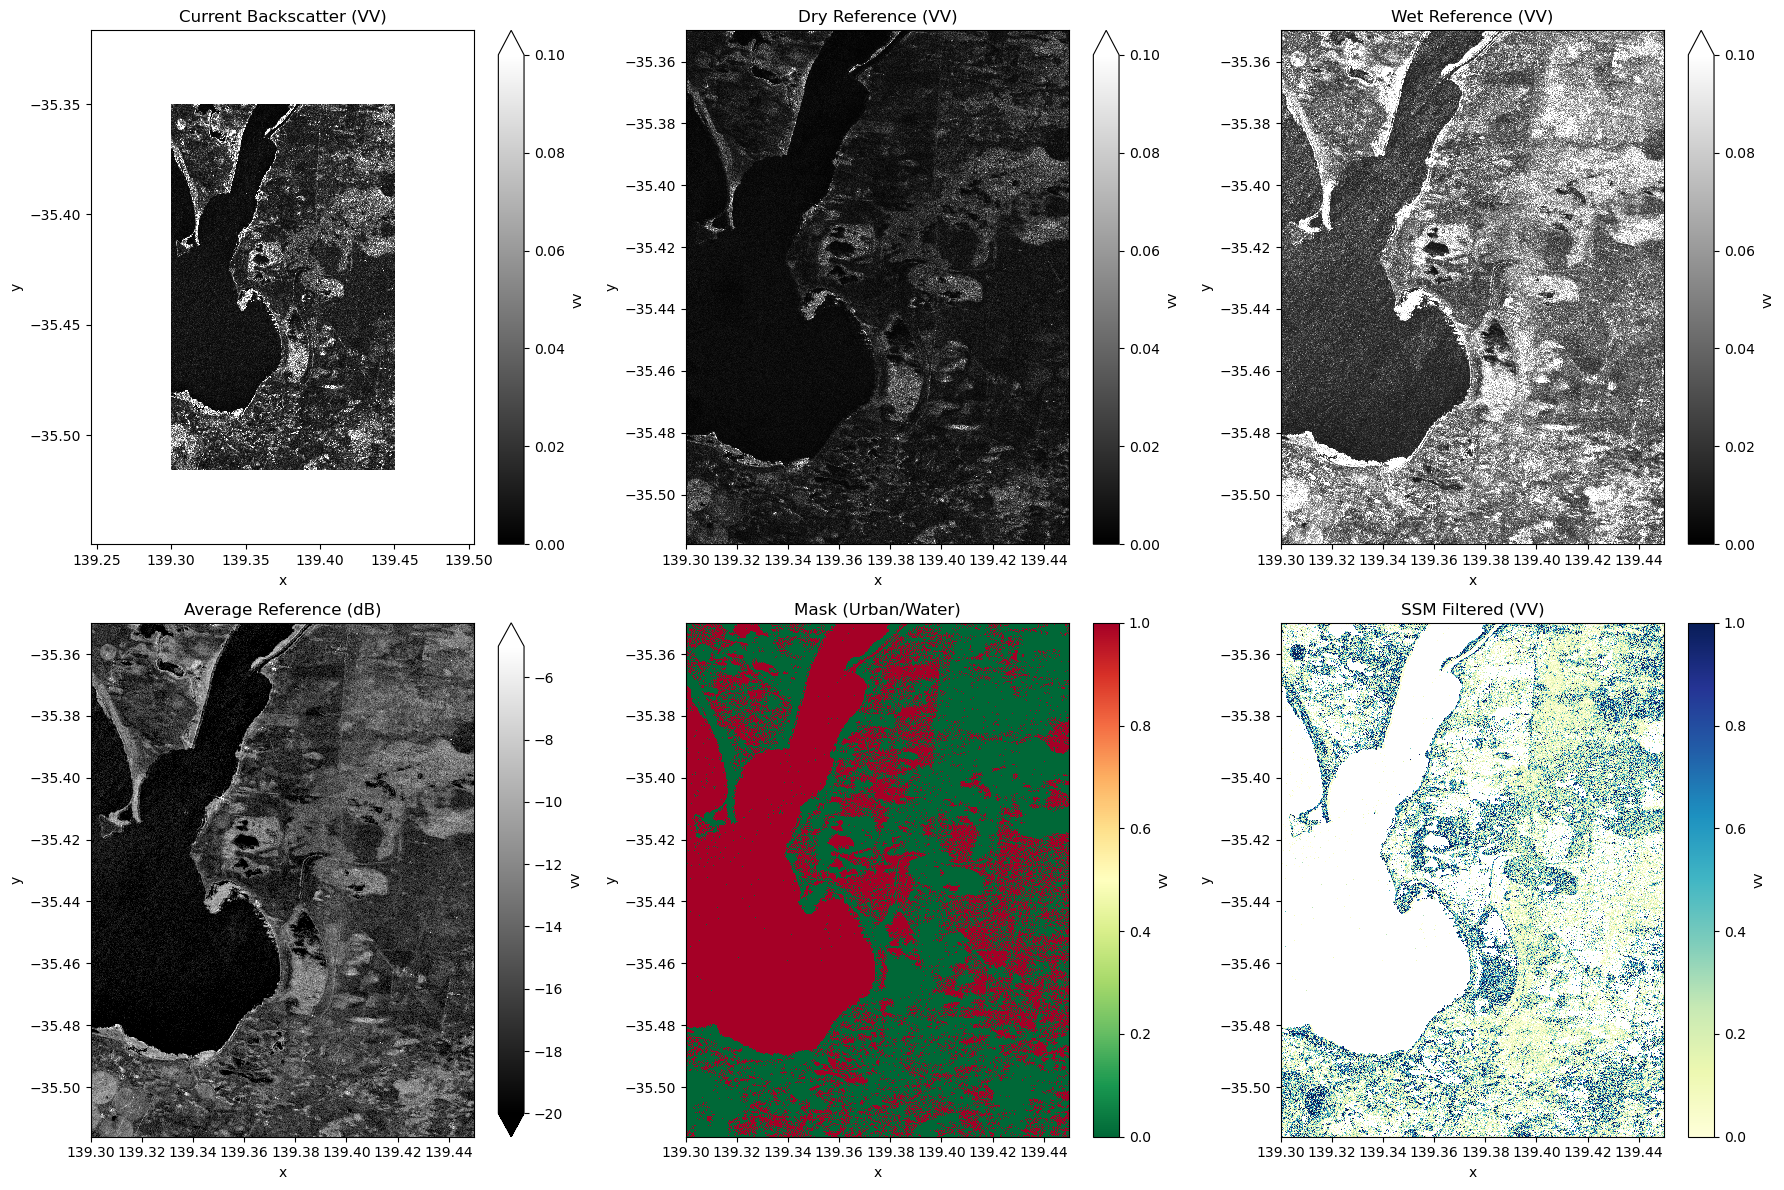

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sigma_0_current.vv.plot.imshow(ax=axes[0, 0], vmin=0, vmax=0.1, cmap='gray', add_colorbar=True)
axes[0, 0].set_title('Current Backscatter (VV)', fontsize=12)

dry_ref.vv.plot.imshow(ax=axes[0, 1], vmin=0, vmax=0.1, cmap='gray', add_colorbar=True)
axes[0, 1].set_title('Dry Reference (VV)', fontsize=12)

wet_ref.vv.plot.imshow(ax=axes[0, 2], vmin=0, vmax=0.1, cmap='gray', add_colorbar=True)
axes[0, 2].set_title('Wet Reference (VV)', fontsize=12)

average_ref_db.vv.plot.imshow(ax=axes[1, 0], vmin=-20, vmax=-5, cmap='gray', add_colorbar=True)
axes[1, 0].set_title('Average Reference (dB)', fontsize=12)

mask.plot.imshow(ax=axes[1, 1], cmap='RdYlGn_r', add_colorbar=True)
axes[1, 1].set_title('Mask (Urban/Water)', fontsize=12)

SSM_vv_filtered.plot.imshow(ax=axes[1, 2], vmin=0, vmax=1, cmap='YlGnBu', add_colorbar=True)
axes[1, 2].set_title('SSM Filtered (VV)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
cluster.shutdown()

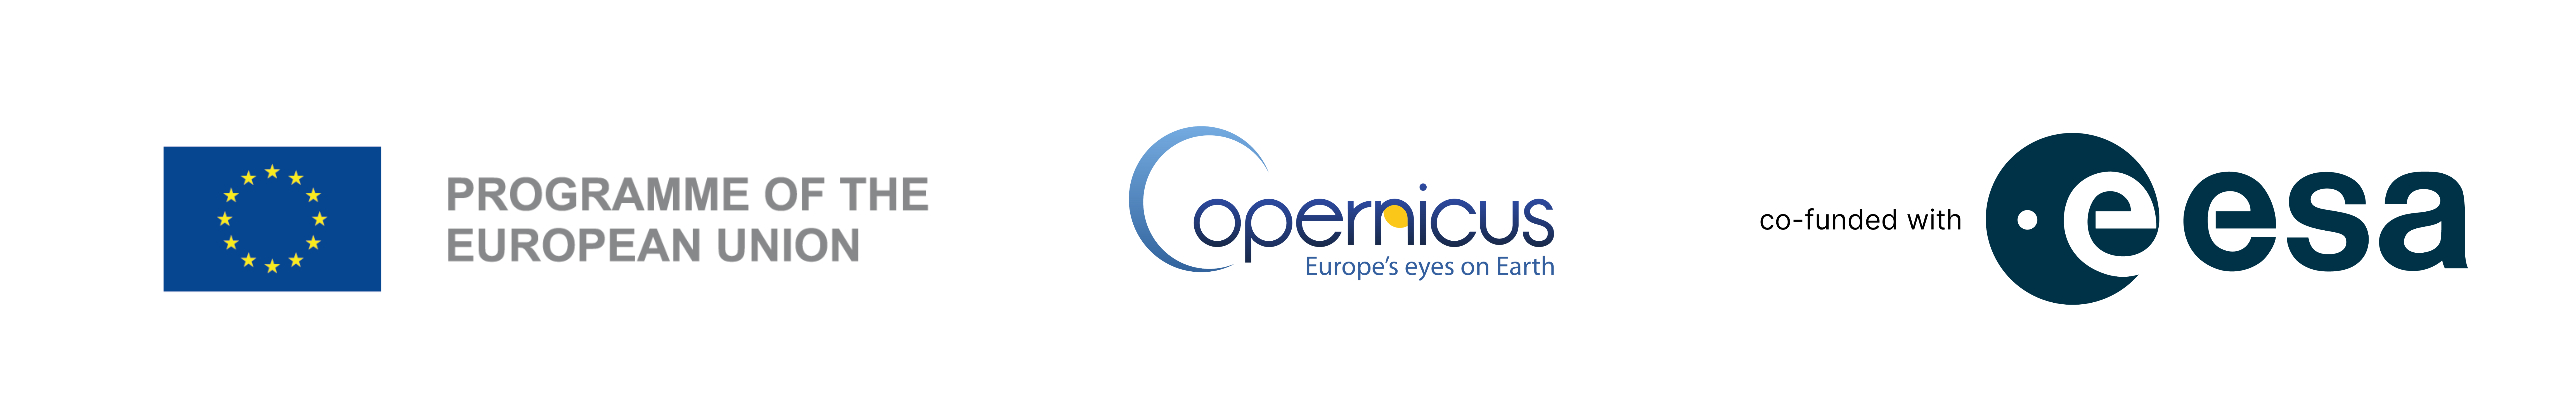